# EDA

### Импортируем библиотеки

In [1]:
!pip install pymupdf wordcloud nltk pandas matplotlib seaborn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 65.5 MB/s eta 0:00:00


## Осмотр файлов

### Напишем функции для извлечения текста из .txt, .pdf, .md.

In [19]:
import re
from pathlib import Path

def text_from_pdf(pdf_path):
    import fitz
    doc = fitz.open(pdf_path)
    text = ""
    for page in doc:
        text += page.get_text()
    doc.close()
    return text

def text_from_txt(txt_path):
    with open(txt_path, 'r', encoding='utf-8', errors='ignore') as f:
        return f.read()

def text_from_md(md_path):
    with open(md_path, 'r', encoding='utf-8', errors='ignore') as f:
        return f.read()

### Функция для самой работы с файлами. Она определяет тип файла и вызывает соответствующий метод для работы.

In [20]:
def extract_text(file_path):
    ext = file_path.suffix.lower()
    if ext == '.pdf':
        return text_from_pdf(file_path)
    elif ext == '.txt':
        return text_from_txt(file_path)
    elif ext == '.md':
        return text_from_md(file_path)
    else:
        print(f"Неподдерживаемый формат: {file_path.name}")
        return ""

### Метрики по файлам

Перед этим моментом мы разумеется сначала загружаем файлы, иначе просто нечего считать будет.

In [21]:
from collections import Counter
import pandas as pd
import nltk
from nltk.corpus import stopwords
from pathlib import Path
nltk.download('stopwords')

stop_words_eng = set(stopwords.words('english'))
stop_words_rus = set(stopwords.words('russian'))
stop_words = stop_words_eng.union(stop_words_rus)

stats = []          # список словарей с характеристиками каждого файла
all_words = []      # список всех слов (wordcloud)

files = list(Path('/content/').glob('*')) # Define 'files' by getting all files in /content/

for file_path in files:
    if not file_path.is_file():
        continue

    text = extract_text(file_path)
    num_chars = len(text)
    num_words = len(text.split())

    # Количество страниц для PDF
    num_pages = 0
    if file_path.suffix.lower() == '.pdf':
        try:
            import fitz
            doc = fitz.open(file_path)
            num_pages = doc.page_count
            doc.close()
        except:
            num_pages = -1

    stats.append({
        'filename': file_path.name,
        'type': file_path.suffix.lower(),
        'size_mb': round(file_path.stat().st_size / (1024*1024), 2),
        'num_chars': num_chars,
        'num_words': num_words,
        'num_pages': num_pages
    })

    # Собираем слова для облака
    words_in_text = re.findall(r'\b[a-zA-Zа-яА-Я]+\b', text.lower())
    filtered = [w for w in words_in_text if w not in stop_words and len(w) > 2]
    all_words.extend(filtered)

df_stats = pd.DataFrame(stats)
print("Статистика собрана. Первые 5 строк:")
df_stats.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Статистика собрана. Первые 5 строк:


,filename,type,size_mb,num_chars,num_words,num_pages
0,dsid_ffbba700729a40b6b4467e3ff5b79a24__2026062...,.txt,0.01,8416,1194,0
1,dsid_ffa4040b7df547c6ba558b7d9abb53bc__2028073...,.txt,0.01,7434,951,0
2,dsid_ffc9914b00dc4f7a994c5cb13cef5ad0__2026072...,.txt,0.01,8467,1315,0
3,dsid_ff71df0a073e4c3f825b7d06c6869218__2026092...,.txt,0.01,6248,855,0
4,dsid_ff206b6c48b644d596ff99a86778aa0c__2026051...,.txt,0.01,5595,853,0


### Гистиграммы распределений

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

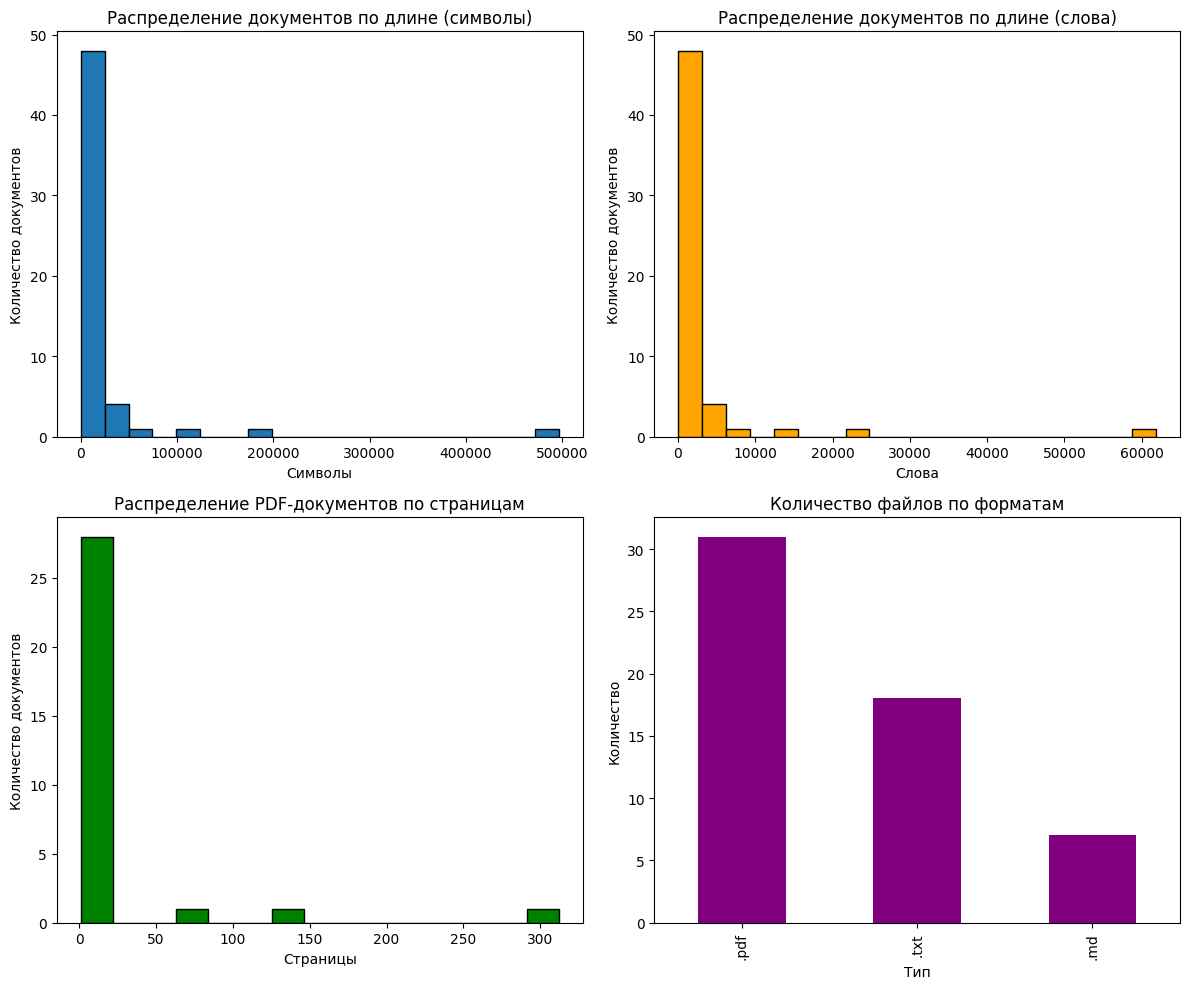

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# по числу символов
axes[0,0].hist(df_stats['num_chars'], bins=20, edgecolor='black')
axes[0,0].set_title('Распределение документов по длине (символы)')
axes[0,0].set_xlabel('Символы')
axes[0,0].set_ylabel('Количество документов')

# по числу слов
axes[0,1].hist(df_stats['num_words'], bins=20, edgecolor='black', color='orange')
axes[0,1].set_title('Распределение документов по длине (слова)')
axes[0,1].set_xlabel('Слова')
axes[0,1].set_ylabel('Количество документов')

# количество страниц для PDF
pdf_stats = df_stats[df_stats['type'] == '.pdf']
if not pdf_stats.empty:
    axes[1,0].hist(pdf_stats['num_pages'], bins=15, edgecolor='black', color='green')
    axes[1,0].set_title('Распределение PDF-документов по страницам')
    axes[1,0].set_xlabel('Страницы')
    axes[1,0].set_ylabel('Количество документов')
else:
    axes[1,0].text(0.5, 0.5, 'Нет PDF-файлов', ha='center')

# количество файлов по типам
df_stats['type'].value_counts().plot(kind='bar', ax=axes[1,1], color='purple')
axes[1,1].set_title('Количество файлов по форматам')
axes[1,1].set_xlabel('Тип')
axes[1,1].set_ylabel('Количество')

plt.tight_layout()
plt.show()

Корпус получился преимущественно из коротких и средних документов, что упрощает извлечение и очистку. Основной вектор при очистке будет направлен в сторону удаления номеров страниц, склейки разорванных слов и удаления лишних пробелов.

## Облако слов

Создадим облако слов, чтобы определить примерно общий контекст документов.

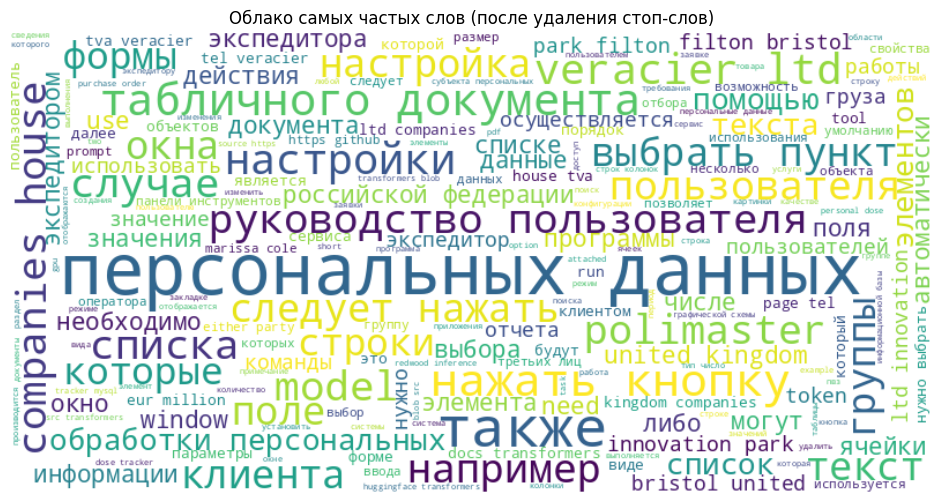

In [24]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(width=800, height=400, background_color='white',
                      max_words=200, colormap='viridis').generate(' '.join(all_words))

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Облако самых частых слов (после удаления стоп-слов)')
plt.show()

## Проверка качества извлечения

Посмотрим насколько качественно извлечается текст. Для этого попробуем вывести первые 500 символов файла после извлечения.

In [25]:
sample_files = [f for f in files if f.is_file()][:5]

for idx, file_path in enumerate(sample_files, 1):
    print(f"\n{'='*80}")
    print(f"Пример {idx}: {file_path.name}")
    print('='*80)
    raw_text = extract_text(file_path)
    print(raw_text[:500])
    print("\n... (показано начало текста)")


Пример 1: dsid_ffbba700729a40b6b4467e3ff5b79a24__20260629-spectramed-rightsize-acceptance-and-cutover-comms.txt
SpectraMed hosted->dedicated: rightsizing proposal, acceptance gates, and cutover timeline

From: Jared Connors <jared.connors@spectramed.io>
To: Grace O'Connor <grace_oconnor@redwood.ai>; Maya Patel <maya.patel@spectramed.io>
Date: Sat, 20 Jun 2026 09:14:00 -0700
Subject: Hosted -> Dedicated migration: need sizing guidance and rough cutover dates

Hi Grace / Maya,

Thanks again for the product walkthrough yesterday. We want to move from Redwood hosted API to a dedicated pool for SpectraMed's in

... (показано начало текста)

Пример 2: dsid_ffa4040b7df547c6ba558b7d9abb53bc__20280730-benchmark-inspection-and-action-log.txt
Benchmark: Latency & Throughput acceptance for Aperture Finance - coordination and results

From: Monica Patel <monica.patel@redwood.com>\nTo: Susan Lam <susan.lam@aperturefinance.com>\nCc: Ben Carter <ben.carter@redwood.com>\nDate: Mon, 30 Jul 2028 09:12:0

Очень похоже на правду, а значит извлечение выполняется вполне корректно.

## Артефакты

Выполним поиск артефактов, которые мешают восприятию текста для модели, таких как номера страниц, лишние пробелым и колонтитулы.

In [27]:
def has_page_numbers(text):
    patterns = [
        r'page \d+', r'стр\.\s*\d+', r'с\.\s*\d+',
        r'-\s*\d+\s*-', r'\[\d+\]', r'\b\d+\s*/\s*\d+\b'
    ]
    found = []
    for pat in patterns:
        if re.search(pat, text, re.IGNORECASE):
            found.append(pat)
    return found

print("Проверка первых 5 файлов на наличие номеров страниц:\n")
for file_path in files[:5]:
    if not file_path.is_file():
        continue
    text = extract_text(file_path)
    problems = has_page_numbers(text)
    if problems:
        print(f"{file_path.name}: найдены паттерны {problems}")
    else:
        print(f"{file_path.name}: номеров страниц не обнаружено")

Проверка первых 5 файлов на наличие номеров страниц:

dsid_ffbba700729a40b6b4467e3ff5b79a24__20260629-spectramed-rightsize-acceptance-and-cutover-comms.txt: найдены паттерны ['-\\s*\\d+\\s*-', '\\b\\d+\\s*/\\s*\\d+\\b']
dsid_ffa4040b7df547c6ba558b7d9abb53bc__20280730-benchmark-inspection-and-action-log.txt: найдены паттерны ['-\\s*\\d+\\s*-', '\\b\\d+\\s*/\\s*\\d+\\b']
dsid_ffc9914b00dc4f7a994c5cb13cef5ad0__20260723-staged-incentive-structure-for-mini-poc.txt: найдены паттерны ['-\\s*\\d+\\s*-']
dsid_ff71df0a073e4c3f825b7d06c6869218__20260922-entitlement-snapshot-collection.txt: найдены паттерны ['-\\s*\\d+\\s*-', '\\b\\d+\\s*/\\s*\\d+\\b']


Проблемные паттерны нашлись в 4 из 5 первых файлов. Это можно объяснить тем, что в корпусе сначала появились .txt, а уже потом .md и .pdf. Соответственно, первые примерно 10 файлов это .txt, а там английские текста, которые к тому же местами могут быть так написаны, что при проверке нашлись переносы слов, лишние пробелы и пр.

## Цифры по файлам

In [28]:
print(f"Всего файлов: {len(df_stats)}")
print(f"Общий размер: {df_stats['size_mb'].sum():.2f} МБ")
print(f"Общее количество символов: {df_stats['num_chars'].sum():,}")
print(f"Общее количество слов: {df_stats['num_words'].sum():,}")
if 'num_pages' in df_stats.columns:
    total_pages = df_stats[df_stats['num_pages'] > 0]['num_pages'].sum()
    print(f"Общее количество страниц для PDF: {total_pages}")

print("\nРаспределение по форматам:")
print(df_stats['type'].value_counts().to_string())
print("\nСамый длинный документ (символы):")
print(df_stats.nlargest(1, 'num_chars')[['filename', 'num_chars']].to_string(index=False))
print("\nСамый короткий документ (символы):")
print(df_stats.nsmallest(1, 'num_chars')[['filename', 'num_chars']].to_string(index=False))

Всего файлов: 56
Общий размер: 26.47 МБ
Общее количество символов: 1,418,880
Общее количество слов: 181,970
Общее количество страниц для PDF: 639

Распределение по форматам:
type
.pdf    31
.txt    18
.md      7

Самый длинный документ (символы):
                           filename  num_chars
instrukciya-po-ehkspluatacii-v8.pdf     496211

Самый короткий документ (символы):
                             filename  num_chars
smithfield_coatings_iso14001_2023.pdf        273


# Очистка файлов

Напишем функцию для очистки текста от мусора, такого как номера страниц, разрывы строк и лишние пробелы и пр.

Функция clean_text очищает текст от артефактов, а именно убирает номера страниц, склеивает слова, которые разорвалиьс из-за перпеноса, удаляет лишние пробелы, табуляции и пустые строки.

In [29]:
def clean_text(text: str, lower: bool = False) -> str:
    patterns = [
        r'-\s*\d+\s*-',           # - 1 -
        r'page\s*\d+',            # page 1, Page 2
        r'стр\.?\s*\d+',          # стр. 1, стр 1
        r'с\.\s*\d+',             # с. 1
        r'\[\s*\d+\s*\]',         # [1]
        r'\b\d+\s*/\s*\d+\b',     # 1/3
    ]
    for pat in patterns:
        text = re.sub(pat, ' ', text, flags=re.IGNORECASE)

    text = re.sub(r'(\w+)-\s*\n\s*(\w+)', r'\1\2', text)
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()

    return text

## Непосредственная очистка файлов

Помимо самой очистки мы сразу добавляем новым файлам метаданные, а именно имя исходника, имя нового файла, тип файла, количество слов и символов, размер в mb.

In [31]:
import shutil
from pathlib import Path

docs_dir = Path("docs")
clean_dir = Path("clean_docs")

if clean_dir.exists():
    shutil.rmtree(clean_dir)
clean_dir.mkdir(exist_ok=True)

cleaned_files_info = []  # для хранения метаданных

for file_path in docs_dir.glob("*"):
    if not file_path.is_file():
        continue

    print(f"Обработка: {file_path.name}")

    # Извлекаем исходный текст
    raw_text = extract_text(file_path)

    # Очищаем текст
    cleaned = clean_text(raw_text, lower=False)

    # Сохраняем очищенный текст в папку clean_docs с расширением .txt
    clean_file_path = clean_dir / f"{file_path.stem}.txt"
    with open(clean_file_path, 'w', encoding='utf-8') as f:
        f.write(cleaned)

    # Собираем метаданные
    cleaned_files_info.append({
        'original_filename': file_path.name,
        'clean_filename': clean_file_path.name,
        'original_type': file_path.suffix.lower(),
        'size_mb': round(file_path.stat().st_size / (1024*1024), 2),
        'cleaned_chars': len(cleaned),
        'cleaned_words': len(cleaned.split()),
    })

print(f"\nСохранено {len(cleaned_files_info)} файлов в папку {clean_dir}")

Обработка: dsid_ffbba700729a40b6b4467e3ff5b79a24__20260629-spectramed-rightsize-acceptance-and-cutover-comms.txt
Обработка: dsid_ffa4040b7df547c6ba558b7d9abb53bc__20280730-benchmark-inspection-and-action-log.txt
Обработка: dsid_ffc9914b00dc4f7a994c5cb13cef5ad0__20260723-staged-incentive-structure-for-mini-poc.txt
Обработка: dsid_ff71df0a073e4c3f825b7d06c6869218__20260922-entitlement-snapshot-collection.txt
Обработка: dsid_ff206b6c48b644d596ff99a86778aa0c__20260514-marketplace-bootcamp-bridge-funding-ask.txt
Обработка: dsid_ffde8aed88034e4f8f3a8a2c768c9bad__20260702-priority-account-sla-exception-discussion.txt
Обработка: Custom Layers and Utilities.md
Обработка: Политика в отношении обработки персональных данных в сервисах.pdf
Обработка: dsid_ff9be427f7da4beabbf883f1c5b22b26__20270505-eval-ready-shortlist-and-pilot-plan.txt
Обработка: dsid_ff75e29f50594805beec7622a9cd1cd3__20261130-locality-topology-failover-data-retention-preflight.txt
Обработка: smithfield_coatings_2021.pdf
Обработка

Добавим еще метаданные, такие как категория файла, количество страниц.

Напишем функцию для определения категории файла.

In [32]:
def infer_category(filename: str) -> str:
    name_lower = filename.lower()
    if 'finance' in name_lower or 'financial' in name_lower:
        return 'finance'
    elif 'legal' in name_lower or 'contract' in name_lower:
        return 'legal'
    elif 'technical' in name_lower or 'tech' in name_lower:
        return 'technical'
    elif 'communication' in name_lower or 'slack' in name_lower or 'email' in name_lower:
        return 'communication'
    else:
        return 'general'

In [33]:
metadata_list = []

for file_path in docs_dir.glob("*"):
    if not file_path.is_file():
        continue

    num_pages = 0
    if file_path.suffix.lower() == '.pdf':
        try:
            import fitz
            doc = fitz.open(file_path)
            num_pages = doc.page_count
            doc.close()
        except:
            num_pages = -1

    metadata_list.append({
        'file_name': file_path.name,
        'file_type': file_path.suffix.lower(),
        'size_mb': round(file_path.stat().st_size / (1024*1024), 2),
        'num_pages': num_pages if num_pages > 0 else None,
        'category': infer_category(file_path.name),
        'source': 'custom_corpus',
    })

df_metadata = pd.DataFrame(metadata_list)
df_metadata.to_csv('metadata.csv', index=False)
print("Метаданные сохранены в metadata.csv")
print(df_metadata.head())

Метаданные сохранены в metadata.csv
                                           file_name file_type  size_mb  \
0  dsid_ffbba700729a40b6b4467e3ff5b79a24__2026062...      .txt     0.01   
1  dsid_ffa4040b7df547c6ba558b7d9abb53bc__2028073...      .txt     0.01   
2  dsid_ffc9914b00dc4f7a994c5cb13cef5ad0__2026072...      .txt     0.01   
3  dsid_ff71df0a073e4c3f825b7d06c6869218__2026092...      .txt     0.01   
4  dsid_ff206b6c48b644d596ff99a86778aa0c__2026051...      .txt     0.01   

   num_pages category         source  
0        NaN  general  custom_corpus  
1        NaN  general  custom_corpus  
2        NaN  general  custom_corpus  
3        NaN  general  custom_corpus  
4        NaN  general  custom_corpus  


## Пример результата

Посмотрим пример обработанного очищенного текста.

In [35]:
clean_dir = Path("clean_docs")
sample_files = list(clean_dir.glob("*.txt"))[:2]

for txt_path in sample_files:
    print(f"\n=== {txt_path.name} ===")
    with open(txt_path, 'r', encoding='utf-8') as f:
        content = f.read()
    print(content[:500])
    print("\n...")


=== dsid_ffbba700729a40b6b4467e3ff5b79a24__20260629-spectramed-rightsize-acceptance-and-cutover-comms.txt ===
SpectraMed hosted->dedicated: rightsizing proposal, acceptance gates, and cutover timeline From: Jared Connors <jared.connors@spectramed.io> To: Grace O'Connor <grace_oconnor@redwood.ai>; Maya Patel <maya.patel@spectramed.io> Date: Sat, 20 Jun 2026 09:14:00 -0700 Subject: Hosted -> Dedicated migration: need sizing guidance and rough cutover dates Hi Grace / Maya, Thanks again for the product walkthrough yesterday. We want to move from Redwood hosted API to a dedicated pool for SpectraMed's infer

...

=== dsid_ffa4040b7df547c6ba558b7d9abb53bc__20280730-benchmark-inspection-and-action-log.txt ===
Benchmark: Latency & Throughput acceptance for Aperture Finance - coordination and results From: Monica Patel <monica.patel@redwood.com>\nTo: Susan Lam <susan.lam@aperturefinance.com>\nCc: Ben Carter <ben.carter@redwood.com>\nDate: Mon, 30 Jul 2028 09:12:00 -0700\nSubject: Benchmark ki

С точки зрения пользователя текст стал менее удобен для прочтения, но с точки зрения модели он стал несомненно легче в изучении.